In [1]:
import json
import os
import cv2
import numpy as np
from tqdm import tqdm
from shutil import copyfile
from ultralytics import YOLO
from ultralytics.data.converter import convert_coco
from matplotlib import pyplot as plt

In [2]:
# Define paths
DATASET_DIR = r"C:\Users\Bakwowi Junior\Documents\school-documents\4th-semester-SS-26\Computer Vision\project\Krones_dataset"
TRAIN_IMAGES_DIR = os.path.join(DATASET_DIR, "train_images")
TEST_IMAGES_DIR = os.path.join(DATASET_DIR, "test_images")
TRAIN_ANNOTATIONS_FILE = os.path.join(DATASET_DIR, "train_annotations.json")
FINAL_TRAIN_IMAGES_DIR = os.path.join(DATASET_DIR, "final_train_images")
# FINAL_TRAIN_LABELS_DIR = os.path.join(DATASET_DIR, "final_train_labels")


if not os.path.exists(FINAL_TRAIN_IMAGES_DIR):
    os.makedirs(FINAL_TRAIN_IMAGES_DIR)

# if not os.path.exists(FINAL_TRAIN_LABELS_DIR):
#     os.makedirs(FINAL_TRAIN_LABELS_DIR)

print(DATASET_DIR, '\n', TRAIN_IMAGES_DIR, '\n', TEST_IMAGES_DIR, '\n', TRAIN_ANNOTATIONS_FILE, '\n', FINAL_TRAIN_IMAGES_DIR)

print(os.path.exists(DATASET_DIR), os.path.exists(TRAIN_IMAGES_DIR), os.path.exists(TEST_IMAGES_DIR), 
              os.path.exists(TRAIN_ANNOTATIONS_FILE), os.path.exists(FINAL_TRAIN_IMAGES_DIR))


C:\Users\Bakwowi Junior\Documents\school-documents\4th-semester-SS-26\Computer Vision\project\Krones_dataset 
 C:\Users\Bakwowi Junior\Documents\school-documents\4th-semester-SS-26\Computer Vision\project\Krones_dataset\train_images 
 C:\Users\Bakwowi Junior\Documents\school-documents\4th-semester-SS-26\Computer Vision\project\Krones_dataset\test_images 
 C:\Users\Bakwowi Junior\Documents\school-documents\4th-semester-SS-26\Computer Vision\project\Krones_dataset\train_annotations.json 
 C:\Users\Bakwowi Junior\Documents\school-documents\4th-semester-SS-26\Computer Vision\project\Krones_dataset\final_train_images
True True True True True


In [ ]:
# Preprocessing steps

def apply_clahe(image):
    # Apply Contrast Limited Adaptive Histogram Equalization to enhance image contrast.
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    return cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)


def calculate_roi_bounds(roi_annotations):
    # Calculate the bounding box of all annotations in an image.
    
    x_coords = []
    y_coords = []
    
    for ann in roi_annotations:
        x, y, w, h = ann['bbox']
        x_coords.extend([x, x + w])
        y_coords.extend([y, y + h])
    
    return int(min(x_coords)), int(max(x_coords)), int(min(y_coords)), int(max(y_coords))


def compute_crop_region(img_shape, x_min, x_max, y_min, y_max, padding=50):
    # Compute crop region with padding, ensuring it stays within image bounds.
    
    x_offset = max(0, x_min - padding)
    y_offset = max(0, y_min - padding)
    
    crop_w = min(img_shape[1], x_max + padding) - x_offset
    crop_h = min(img_shape[0], y_max + padding) - y_offset
    
    return x_offset, y_offset, crop_w, crop_h


def is_annotation_center_in_crop(bbox, x_offset, y_offset, crop_w, crop_h):
    # Check if the center of a bounding box is within the crop region.
    
    new_x = bbox[0] - x_offset
    new_y = bbox[1] - y_offset
    center_x = new_x + (bbox[2] / 2)
    center_y = new_y + (bbox[3] / 2)
    
    return 0 <= center_x <= crop_w and 0 <= center_y <= crop_h


def adjust_annotation(ann, x_offset, y_offset, ann_id):
    # Adjust annotation coordinates to match cropped image.
    
    old_bbox = ann['bbox']
    new_ann = ann.copy()
    new_ann['bbox'] = [
        old_bbox[0] - x_offset,
        old_bbox[1] - y_offset,
        old_bbox[2],
        old_bbox[3]
    ]
    new_ann['id'] = ann_id
    return new_ann

In [ ]:
# Function to detect circles using Hough Transform, 
# crop the image around the detected circle, 
# and adjust annotations accordingly
def crop_image_and_adjust_annotations(json_path, img_dir, output_dir, padding=50):
    # Crop images based on annotation ROI and adjust annotation coordinates.
    
    with open(json_path, 'r') as f:
        coco_data = json.load(f)

    # Build annotation map for quick lookup
    ann_map = {}
    for ann in tqdm(coco_data['annotations'], desc="Processing annotations", unit="annotation", 
                    ncols=80, bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]"):
        ann_map.setdefault(ann['image_id'], []).append(ann)

    new_images = []
    new_annotations = []
    ann_id_counter = 1

    for img_info in tqdm(coco_data['images'], desc="Processing images", unit="image", 
                        ncols=80, bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]"):
        img_id = img_info['id']
        filename = img_info['file_name']
        img_path = os.path.join(img_dir, filename)
        img = cv2.imread(img_path)
        
        if img is None:
            print(f"Error: Could not load image at {img_path}. Check the file path!")
            continue

        # Skip images without annotations
        if img_id not in ann_map:
            print(f"Warning: No annotations found for image ID {img_id}. Skipping.")
            continue

        # Calculate ROI bounds from all annotations were the category id is 22 (ROI)
        roi_annotations = [ann for ann in ann_map[img_id] if ann['category_id'] == 22]
        x_min, x_max, y_min, y_max = calculate_roi_bounds(roi_annotations)
        
        # Compute crop region with padding
        x_offset, y_offset, crop_w, crop_h = compute_crop_region(
            img.shape, x_min, x_max, y_min, y_max, padding
        )
        
        # Crop and enhance image
        cropped_img = img[y_offset:y_offset+crop_h, x_offset:x_offset+crop_w]
        cropped_img = apply_clahe(cropped_img)
        cv2.imwrite(os.path.join(output_dir, filename), cropped_img)
        
        # Process annotations for this image
        for ann in ann_map[img_id]:
            # Check if annotation center is still within crop region
            if is_annotation_center_in_crop(ann['bbox'], x_offset, y_offset, crop_w, crop_h):
                adjusted_ann = adjust_annotation(ann, x_offset, y_offset, ann_id_counter)
                new_annotations.append(adjusted_ann)
                ann_id_counter += 1
        
        # Update image metadata
        new_img_info = img_info.copy()
        new_img_info['width'] = crop_w
        new_img_info['height'] = crop_h
        new_images.append(new_img_info)

    # Save adjusted COCO JSON
    output_coco = {
        "info": {
            "year": 2026,
            "version": "1.0",
            "description": "For object detection",
            "date_created": "2026"
        },
        "images": new_images,
        "annotations": new_annotations,
        "categories": coco_data['categories']
        }
    
    with open(os.path.join(output_dir, 'adjusted_annotations.json'), 'w') as f:
        json.dump(output_coco, f)

In [9]:
# run the preprocessing steps
crop_image_and_adjust_annotations(TRAIN_ANNOTATIONS_FILE, TRAIN_IMAGES_DIR, DATASET_DIR)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Bakwowi Junior\\Documents\\school-documents\\4th-semester-SS-26\\Computer Vision\\project\\Krones_dataset/train_annotations.json'

In [ ]:
#  Convert annotations in COCO format to YOLO format
# Theimages and JSON file should be in the same parent folder
def convert_annotations_coco_to_yolo_format(coco_json, output_dir):
    return convert_coco(
        labels_dir=coco_json,
        save_dir=output_dir,
        use_segments=False,
        cls91to80=False
    )

convert_annotations_coco_to_yolo_format(
    coco_json=TRAIN_ANNOTATIONS_FILE,
    output_dir=DATASET_DIR
)

In [ ]:
# Define the YOLO model and evolve hyperparameters
model = YOLO('yolo26n.pt')
model.evolve(
    data='image_data.yaml', 
    epochs=10,        # Short bursts to test settings
    iterations=100,   # 100 different 'mutations' of hyperparameters
    imgsz=640, 
    device=0,
    # Specific industrial priors:
    scale=0.5,        # Focus on small objects
    fliplr=0.5,       # Bottles rotate, so symmetry matters
    mosaic=1.0        # Mandatory for detecting multiple small spots
)

# Final Training
model.train(
    data='image_data.yaml',
    epochs=150,
    imgsz=640,
    batch=32,
    patience=25,
    # High-speed industrial augmentations
    mixup=0.2, 
    mosaic=1.0, 
    degrees=180.0 # Bottles spin on the line
)

In [ ]:
# Mapping Thresholds (Class Name -> Pixel Area Threshold)
CONDITIONALLY_FAULTY = {
    "Air bubble": {"single": 500, "total": 1200}, # Example: 3 bubbles of 450px = Reject
    "Chip": {"single": 200, "total": 400},
    "Contamination light": {"single": 180, "total": 500},
    "Glass imperfection": {"single": 100, "total": 300},
    "Scuffing": {"single": 75000, "total": 100000},
    "Scuffing heavy": {"single": 1200, "total": 2500}
}

ALWAYS_FAULTY = [
    "Break / Crack", "Circlip", "Contamination dark", "Crown cap", 
    "Foil / Semitransparent", "Foreign object - manual cleaning", 
    "Foreign object - washing machine", "Glass shard", "Insect", 
    "Label", "Liquid", "Mold", "No base visible", "Paint residue", 
    "Straw", "Yeast residue"
]

def final_decision(results):
    detections = results[0].boxes
    if len(detections) == 0:
        return 0, "Clear"

    # Trackers for cumulative area per class
    class_area_totals = {} 
    
    for det in detections:
        label = model.names[int(det.cls)]
        area = float(det.xywh[0][2] * det.xywh[0][3])

        # 1. Immediate Rejection (Faulty)
        if label in ALWAYS_FAULTY:
            return 1, f"Critical Failure: {label}"

        # 2. Check Individual & Cumulative (Conditionally Faulty)
        if label in CONDITIONALLY_FAULTY:
            limits = CONDITIONALLY_FAULTY[label]
            
            # Check single object threshold
            if area > limits["single"]:
                return 1, f"Reject: Single {label} too large ({area:.0f}px)"
            
            # Update running total for this class
            class_area_totals[label] = class_area_totals.get(label, 0) + area
            
            # Check cumulative threshold
            if class_area_totals[label] > limits["total"]:
                return 1, f"Reject: Cumulative {label} exceeded ({class_area_totals[label]:.0f}px)"

    return 0, "Pass"

In [ ]:
#Load the trained model
# model = YOLO('models/example.pt')

# Run validation
# This generates the Confusion Matrix, P-curve, R-curve, and F1-curve automatically
# results = model.val(data='image_data.yaml', imgsz=640, split='val')

# # Access specific metrics programmatically
# print(f"Mean Precision: {results.results_dict['metrics/precision(B)']:.4f}")
# print(f"Mean Recall: {results.results_dict['metrics/recall(B)']:.4f}")
# print(f"Mean F1-Score: {results.results_dict['metrics/f1(B)']:.4f}")
# print(f"mAP@50 (Accuracy): {results.results_dict['metrics/mAP50(B)']:.4f}")

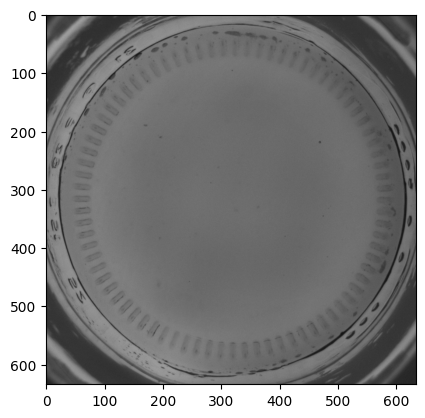

In [55]:
sample_img = cv2.imread('sample3.png')


# apply hough circle transform to detect and draw circles in the image
def detect_circles(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        # Median blur is better for brown glass noise than Gaussian
    # gray = cv2.medianBlur(gray, 9) 
    
    circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp=1.2, minDist=300,
                                param1=50, param2=40, minRadius=180, maxRadius=300)
    return circles


circles = np.uint16(np.around(detect_circles(sample_img)))
x, y, r = circles[0, 0]
clipped_img = sample_img[max(0, y-r-20):y+r+20, max(0, x-r-20):x+r+20]
plt.imshow(cv2.cvtColor(clipped_img, cv2.COLOR_BGR2RGB))

# # detect circles in the final image
# circles = detect_circles(sample_img)

# # draw the circles on the image
# if circles is not None:
#     circles = np.uint16(np.around(circles))
#     for i in circles[0, :]:
#         cv2.circle(sample_img, (i[0], i[1]), i[2], (0, 255, 0), 2)
#         cv2.circle(sample_img, (i[0], i[1]), 2, (0, 0, 255), 3)


# # apply clahe to the image
# lab = cv2.cvtColor(sample_img, cv2.COLOR_BGR2LAB)
# l, a, b = cv2.split(lab)
# clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
# cl = clahe.apply(l)
# limg = cv2.merge((cl, a, b))
# final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)


# # save the final image
# cv2.imwrite('final_sample3.png', final_img)
# cv2.imwrite('updated_sample3.png', sample_img)

# # display the original and final images
# plt.subplot(1, 2, 1)
# plt.imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
# plt.title('Original Image')
# plt.axis('off')

# plt.subplot(1, 2, 2)
# plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
# plt.title('CLAHE Image')
# plt.axis('off')
# plt.show()